# Lab 2 · Build and audit a point-in-time SEC retrieval system

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leippold/finance-nlp-workshop/blob/main/colabs/02_point_in_time_rag_sec.ipynb)

**90-minute graduate lab.** Build a RAG system as an information pipeline—not
as a chat box. You will enforce an as-of filtration, implement BM25 and
character retrieval, evaluate eight paraphrased finance questions, add MiniLM
embeddings and an optional cross-encoder reranker, and emit an evidence
certificate. A live extension extracts and chunks Microsoft MD&A from SEC-API.

| Route | Time | What you build |
|---|---:|---|
| **Core · point-in-time retrieval** | 35 min | eligibility gate, BM25, TF-IDF, RRF, leakage audit |
| **Deep · neural retrieval** | 35 min | bi-encoder matrix, hybrid retrieval, cross-encoder reranking |
| **Live · real filing ingestion** | 20 min | SEC query/extraction, bounded chunking, cached corpus |

The fast route uses 12 frozen, accession-linked passages and no key. The model
and live routes are explicit switches, so classroom Wi-Fi cannot break the
conceptual experiment.

## 1. Load and audit the frozen corpus

The 2025 filing repeats the fiscal-2024 comparatives. Its numbers are true but
unavailable at the 2024 decision timestamp—the exact trap we want to expose.

In [1]:
from pathlib import Path
from io import BytesIO
from collections import Counter
import math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    def display(value): print(value)
from sklearn.feature_extraction.text import TfidfVectorizer

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'blue': '#22577D', 'blue_light': '#5E92B5', 'gold': '#B5862E',
    'gold_light': '#E4D3A6', 'ink': '#1B1915', 'slate': '#6C6457',
    'grid': '#D9D0C0', 'open': '#FBF8F1',
}
RUN_HUGGINGFACE = False   #@param {type:"boolean"}
RUN_RERANKER = False      #@param {type:"boolean"}
REFRESH_FROM_SEC = False  #@param {type:"boolean"}
USE_SEC_API_SERVICE = False  #@param {type:"boolean"}
RUN_SEC_EXTRACTOR = False    #@param {type:"boolean"}
if RUN_RERANKER and not RUN_HUGGINGFACE:
    raise ValueError('RUN_RERANKER requires RUN_HUGGINGFACE=True.')

def load_teaching_csv(filename, **read_csv_kwargs):
    candidates = [Path('../teaching-data')/filename, Path('teaching-data')/filename,
                  Path('/content')/filename, Path(filename)]
    local = next((path for path in candidates if path.exists()), None)
    if local is not None:
        print('Loading', local)
        return pd.read_csv(local, **read_csv_kwargs)
    try:
        from google.colab import files
    except ImportError as exc:
        raise FileNotFoundError(
            f'{filename} not found. Place it in teaching-data/ or the current directory.'
        ) from exc
    print(f'Upload {filename} from the PR teaching-data folder.')
    uploaded = files.upload()
    if filename not in uploaded:
        raise FileNotFoundError(f'Expected {filename}; received {list(uploaded)}')
    return pd.read_csv(BytesIO(uploaded[filename]), **read_csv_kwargs)

docs = load_teaching_csv('sec_point_in_time_passages.csv', dtype={'cik': str})
docs['filed_date'] = pd.to_datetime(docs.filed_date)
DECISION_DATE = pd.Timestamp('2024-08-01')
QUERY = 'What were Microsoft fiscal 2024 revenue and operating income?'
docs['eligible'] = docs.filed_date <= DECISION_DATE
display(docs[['passage_id','filed_date','fiscal_year','section','relevant','eligible']])
assert docs.query('relevant == 1').eligible.tolist() == [True, False]

Loading ../teaching-data/sec_point_in_time_passages.csv
             passage_id filed_date  ...  relevant eligible
0        msft24_summary 2024-07-30  ...         1     True
1          msft24_cloud 2024-07-30  ...         0     True
2   msft24_productivity 2024-07-30  ...         0     True
3    msft24_intelligent 2024-07-30  ...         0     True
4       msft24_personal 2024-07-30  ...         0     True
5         msft24_office 2024-07-30  ...         0     True
6         msft24_gaming 2024-07-30  ...         0     True
7             msft24_rd 2024-07-30  ...         0     True
8    msft25_comparative 2025-07-30  ...         1    False
9        msft25_summary 2025-07-30  ...         0    False
10         msft25_cloud 2025-07-30  ...         0    False
11      msft25_segments 2025-07-30  ...         0    False

[12 rows x 6 columns]


### The system boundary

The timestamp gate belongs before retrieval. A model may estimate relevance;
it may not retroactively make a filing available. The certificate keeps that
distinction visible at the answer boundary.

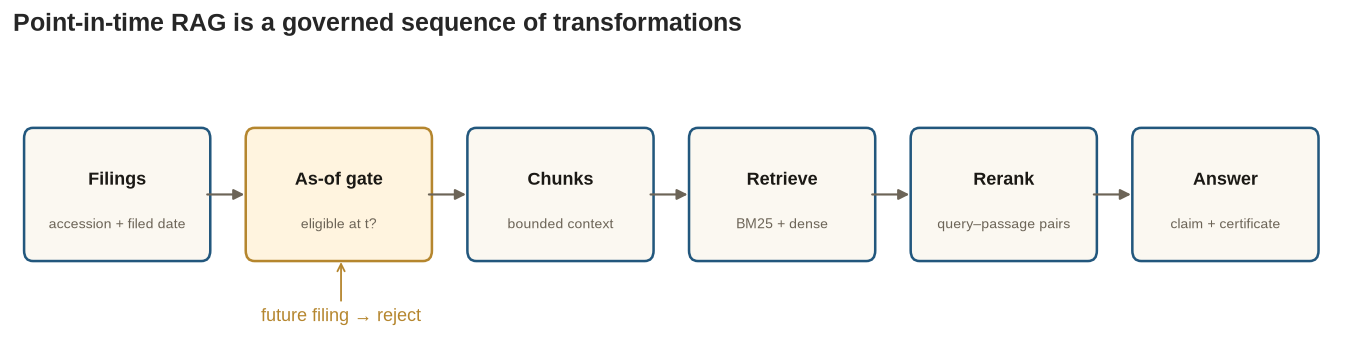

In [2]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

stages = [('Filings', 'accession + filed date'), ('As-of gate', 'eligible at t?'),
          ('Chunks', 'bounded context'), ('Retrieve', 'BM25 + dense'),
          ('Rerank', 'query–passage pairs'), ('Answer', 'claim + certificate')]
fig, ax = plt.subplots(figsize=(13.2, 3.0))
ax.set_xlim(0, 6); ax.set_ylim(0, 1.15); ax.axis('off')
for i, (title, subtitle) in enumerate(stages):
    gate = i == 1
    ax.add_patch(FancyBboxPatch((i+.08,.34),.78,.45,
                 boxstyle='round,pad=.03,rounding_size=.04',
                 facecolor='#fff4df' if gate else COLORS['open'],
                 edgecolor=COLORS['gold'] if gate else COLORS['blue'],
                 linewidth=1.4))
    ax.text(i+.47,.62,title,ha='center',va='center',weight='bold',color=COLORS['ink'])
    ax.text(i+.47,.45,subtitle,ha='center',va='center',fontsize=8,color=COLORS['slate'])
    if i < 5:
        ax.add_patch(FancyArrowPatch((i+.86,.565),(i+1.06,.565),arrowstyle='-|>',
                     mutation_scale=12,color=COLORS['slate'],linewidth=1.2))
ax.annotate('future filing → reject', xy=(1.48,.32), xytext=(1.48,.08), ha='center',
            color=COLORS['gold'], arrowprops={'arrowstyle':'->','color':COLORS['gold']})
ax.set_title('Point-in-time RAG is a governed sequence of transformations',
             loc='left', fontsize=14, weight='bold')
plt.show()

### Predict before running

The future filing uses the exact query terms and repeats both requested
figures. Predict whether it will enter top-3 retrieval, and whether filtering
the top-3 *after* retrieval is equivalent to filtering the corpus first.

## 2. Two inspectable retrieval channels

- **BM25** rewards matching financial terms with length normalization.
- **Character TF-IDF** is a lightweight semantic proxy that handles variants
  such as `fiscal-2024` versus `fiscal 2024` without a model download.
- **Fusion** uses reciprocal rank fusion (RRF), so score scales need not match.

In [3]:
TOKEN = re.compile(r'[a-z0-9]+')
def tokenize(text): return TOKEN.findall(text.lower())

def bm25_scores(query, passages, k1=1.5, b=0.75):
    toks = [tokenize(x) for x in passages]
    q = tokenize(query); N = len(toks); avgdl = np.mean([len(x) for x in toks])
    df = Counter(t for row in toks for t in set(row))
    scores = []
    for row in toks:
        tf = Counter(row); score = 0.0
        for term in q:
            f = tf[term]
            idf = math.log(1 + (N - df[term] + .5)/(df[term] + .5))
            score += idf * (f*(k1+1))/(f + k1*(1-b+b*len(row)/avgdl)) if f else 0
        scores.append(score)
    return np.array(scores)

def retrieve(frame, query=QUERY, method='fusion'):
    frame = frame.copy().reset_index(drop=True)
    bm = bm25_scores(query, frame.passage)
    vec = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5)).fit(frame.passage.tolist()+[query])
    X = vec.transform(frame.passage); q = vec.transform([query])
    ch = (X @ q.T).toarray().ravel()  # rows are L2-normalized
    if method == 'bm25': score = bm
    elif method == 'char': score = ch
    else:
        rb = pd.Series((-bm).argsort().argsort()+1, index=frame.index)
        rc = pd.Series((-ch).argsort().argsort()+1, index=frame.index)
        score = (1/(60+rb) + 1/(60+rc)).to_numpy()
    frame['score'] = score
    return frame.sort_values(['score','passage_id'], ascending=[False,True]).reset_index(drop=True)

def metrics(ranking, k, decision_date=DECISION_DATE):
    top = ranking.head(k)
    eligible_rel = docs.query('relevant == 1 and eligible').passage_id
    hit_ids = set(top.query('relevant == 1 and filed_date <= @decision_date').passage_id)
    first = np.flatnonzero((top.relevant.eq(1) & top.filed_date.le(decision_date)).to_numpy())
    return {'Recall@k': len(hit_ids)/len(eligible_rel), 'MRR': 0 if not len(first) else 1/(first[0]+1),
            'Future contamination': int(top.filed_date.gt(decision_date).sum())}

## 3. Run the counterfactual: unsafe versus point-in-time

The only difference is the order of operations. In the safe system, the as-of
gate changes the candidate set **before** any score is computed.

In [4]:
unsafe = retrieve(docs, method='fusion')
safe = retrieve(docs.query('eligible'), method='fusion')
cols = ['passage_id','filed_date','section','relevant','score','passage']
print('UNSAFE: retrieval over all filings')
display(unsafe.head(3)[cols])
print('SAFE: as-of gate before retrieval')
display(safe.head(3)[cols])

result = pd.DataFrame({
    'unsafe corpus': metrics(unsafe, 3),
    'point-in-time corpus': metrics(safe, 3),
})
display(result)
assert result.loc['Future contamination', 'point-in-time corpus'] == 0
assert result.loc['Recall@k', 'point-in-time corpus'] == 1

UNSAFE: retrieval over all filings
           passage_id  ...                                            passage
0      msft24_summary  ...  Microsoft reported fiscal 2024 revenue of $245...
1  msft25_comparative  ...  The fiscal 2025 10-K comparative table lists M...
2      msft25_summary  ...  Microsoft reported fiscal 2025 revenue of $281...

[3 rows x 6 columns]
SAFE: as-of gate before retrieval
        passage_id  ...                                            passage
0   msft24_summary  ...  Microsoft reported fiscal 2024 revenue of $245...
1     msft24_cloud  ...  Microsoft Cloud revenue increased 23% to $137....
2  msft24_personal  ...  More Personal Computing fiscal 2024 operating ...

[3 rows x 6 columns]
                      unsafe corpus  point-in-time corpus
Recall@k                        1.0                   1.0
MRR                             1.0                   1.0
Future contamination            2.0                   0.0


In [5]:
# Filtering after top-k is not equivalent: it can leave fewer than k usable passages.
late_filtered = unsafe.head(3).query('filed_date <= @DECISION_DATE')
comparison = pd.DataFrame({
    'pipeline': ['retrieve all → top 3 → filter', 'filter corpus → retrieve → top 3'],
    'usable passages': [len(late_filtered), len(safe.head(3))],
    'top eligible evidence': [late_filtered.iloc[0].passage_id if len(late_filtered) else None, safe.iloc[0].passage_id]
})
display(comparison)

                           pipeline  usable passages top eligible evidence
0     retrieve all → top 3 → filter                1        msft24_summary
1  filter corpus → retrieve → top 3                3        msft24_summary


## 4. Evaluate a retriever, not an anecdote

One question can make almost any retriever look good. The frozen corpus also
supports eight issuer-specific questions with exact target passage IDs. Some
queries deliberately paraphrase filing language (for example, “innovation
spending” for R&D), creating useful lexical failures.

We report Hit@1, Hit@3, and mean reciprocal rank (MRR). With one relevant
passage per query, reciprocal rank is $1/r_q$, where $r_q$ is the target rank.

In [6]:
EVAL_QUERIES = pd.DataFrame([
    ('Q1', 'What were Microsoft fiscal 2024 revenue and operating income?', 'msft24_summary'),
    ('Q2', 'How large was Microsoft Cloud revenue in FY2024?', 'msft24_cloud'),
    ('Q3', 'What was operating profit for the productivity segment in 2024?', 'msft24_productivity'),
    ('Q4', 'How much operating income came from the cloud infrastructure segment?', 'msft24_intelligent'),
    ('Q5', 'What did the personal computing segment earn in fiscal 2024?', 'msft24_personal'),
    ('Q6', 'How did Office subscriptions and traditional licences move?', 'msft24_office'),
    ('Q7', 'How did gaming sales change after the Activision acquisition?', 'msft24_gaming'),
    ('Q8', 'How much did Microsoft spend on innovation in FY2024?', 'msft24_rd'),
], columns=['query_id','query','target_passage_id'])

def target_rank(ranking, target_passage_id):
    locations = np.flatnonzero(ranking.passage_id.eq(target_passage_id).to_numpy())
    return np.inf if not len(locations) else int(locations[0] + 1)

def summarize_ranks(rows):
    frame = pd.DataFrame(rows)
    summary = frame.groupby('method').agg(
        Hit_at_1=('rank', lambda value: np.mean(np.asarray(value) <= 1)),
        Hit_at_3=('rank', lambda value: np.mean(np.asarray(value) <= 3)),
        MRR=('rank', lambda value: np.mean(1/np.asarray(value, dtype=float))),
    )
    return frame, summary.sort_values('MRR', ascending=False)

lexical_rows = []
eligible_docs = docs.query('eligible').copy()
for query_row in EVAL_QUERIES.itertuples(index=False):
    for method in ['bm25', 'char', 'fusion']:
        ranking = retrieve(eligible_docs, query=query_row.query, method=method)
        lexical_rows.append({
            'query_id': query_row.query_id, 'method': method,
            'rank': target_rank(ranking, query_row.target_passage_id),
        })
lexical_results, lexical_summary = summarize_ranks(lexical_rows)
display(lexical_summary.round(3))

        Hit_at_1  Hit_at_3    MRR
method                           
char       0.875       1.0  0.917
fusion     0.875       1.0  0.917
bm25       0.750       1.0  0.854


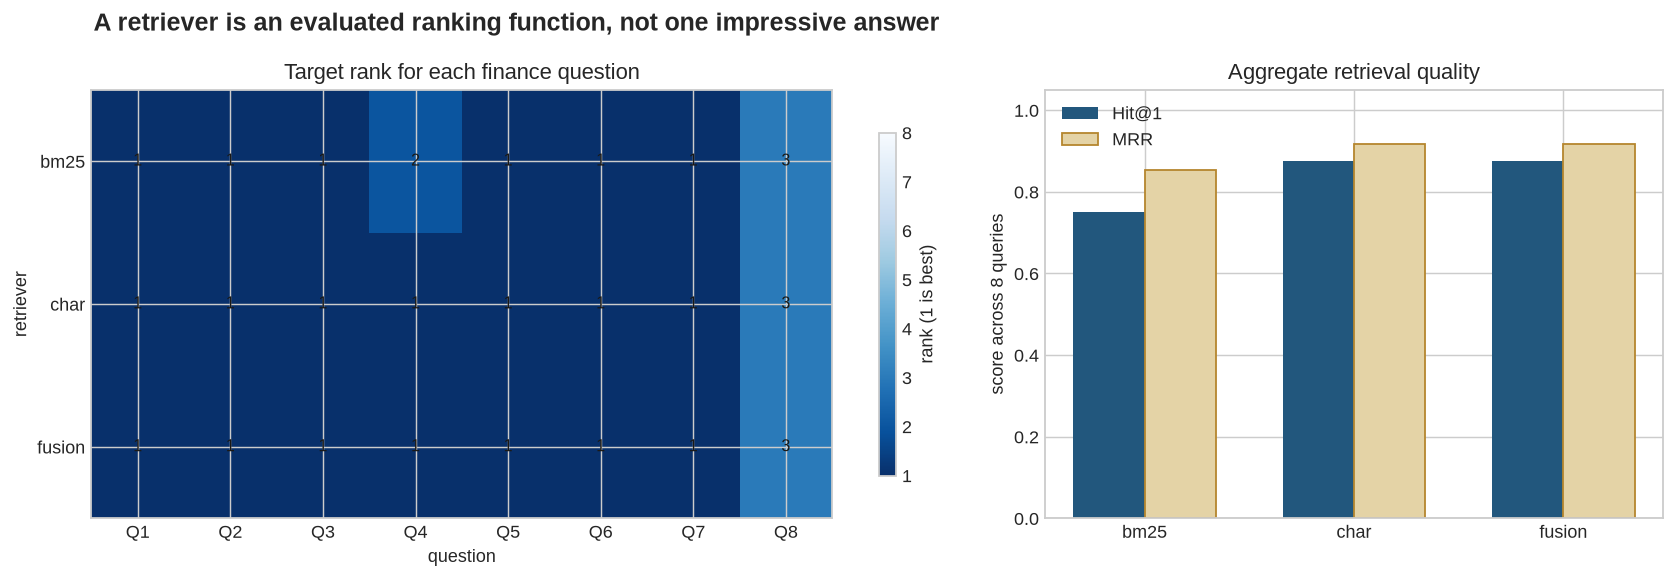

In [7]:
rank_matrix = lexical_results.pivot(index='method', columns='query_id', values='rank').loc[
    ['bm25','char','fusion']]
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.5),
                         gridspec_kw={'width_ratios':[1.5,1]})
image = axes[0].imshow(rank_matrix, aspect='auto', cmap='Blues_r', vmin=1, vmax=8)
for row in range(rank_matrix.shape[0]):
    for column in range(rank_matrix.shape[1]):
        axes[0].text(column, row, int(rank_matrix.iloc[row,column]),
                     ha='center', va='center', color=COLORS['ink'], fontsize=9)
axes[0].set(title='Target rank for each finance question', xlabel='question', ylabel='retriever')
axes[0].set_xticks(range(len(rank_matrix.columns)), rank_matrix.columns)
axes[0].set_yticks(range(len(rank_matrix.index)), rank_matrix.index)
fig.colorbar(image, ax=axes[0], label='rank (1 is best)', shrink=.8)

plotted = lexical_summary.loc[['bm25','char','fusion']]
x = np.arange(len(plotted))
width = .34
axes[1].bar(x-width/2, plotted.Hit_at_1, width, color=COLORS['blue'], label='Hit@1')
axes[1].bar(x+width/2, plotted.MRR, width, color=COLORS['gold_light'],
            edgecolor=COLORS['gold'], label='MRR')
axes[1].set_xticks(x, plotted.index)
axes[1].set_ylim(0, 1.05)
axes[1].set(title='Aggregate retrieval quality', ylabel='score across 8 queries', xlabel='')
axes[1].legend(frameon=False)
fig.suptitle('A retriever is an evaluated ranking function, not one impressive answer',
             x=.06, ha='left', fontsize=14, weight='bold')
plt.tight_layout(); plt.show()

## 5. Deep path: dense retrieval with a small Transformer

Lexical retrieval asks whether the query and passage share terms. Dense
retrieval asks whether a Transformer maps them to nearby vectors. We use
[`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2),
which produces normalized 384-dimensional sentence embeddings. Set the switch
below to `True`; `HF_TOKEN` is read from Colab secrets when available.

In [8]:
EMBEDDING_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'
RERANKER_MODEL = 'cross-encoder/ms-marco-MiniLM-L6-v2'
if RUN_HUGGINGFACE:
    import subprocess, sys
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'sentence-transformers>=5,<7', 'accelerate>=1,<3'
    ])
    print('Dense retrieval path enabled.')
else:
    print('Fast path active. Set RUN_HUGGINGFACE=True for dense retrieval.')

Fast path active. Set RUN_HUGGINGFACE=True for dense retrieval.


### 5.1 Encode documents and all queries once

Because the embeddings are L2-normalized, their dot product is cosine
similarity. The point-in-time gate still comes first: semantic relevance
cannot make a future document eligible.

In [9]:
if RUN_HUGGINGFACE:
    from sentence_transformers import SentenceTransformer
    from sklearn.decomposition import PCA

    def colab_secret(name):
        try:
            from google.colab import userdata
            return userdata.get(name)
        except Exception:
            return None

    hf_token = colab_secret('HF_TOKEN')
    encoder = SentenceTransformer(EMBEDDING_MODEL, token=hf_token)
    document_embeddings = encoder.encode(
        docs.passage.tolist(), normalize_embeddings=True, show_progress_bar=False)
    query_embeddings = encoder.encode(
        EVAL_QUERIES['query'].tolist(), normalize_embeddings=True,
        show_progress_bar=False)
    dense_score_matrix = query_embeddings @ document_embeddings.T
    primary_query_embedding = query_embeddings[0]
    docs['dense_score'] = document_embeddings @ primary_query_embedding
    print('document matrix:', document_embeddings.shape,
          '| query matrix:', query_embeddings.shape)
    display(docs.sort_values('dense_score', ascending=False)[
        ['passage_id','filed_date','eligible','relevant','dense_score','passage']
    ].head(6).round({'dense_score':3}))

### 5.2 Compare channels, fuse ranks, and optionally rerank pairs

Score magnitudes are not commensurate across BM25, TF-IDF and dense retrieval.
Reciprocal rank fusion combines their orderings instead of pretending that
their raw scores live on one scale. A bi-encoder scores query and passage
vectors cheaply and independently; an optional cross-encoder then reads each
candidate pair jointly. The reranker is allowed to reorder only the top five:
it cannot recover a target discarded by first-stage retrieval.

In [10]:
if RUN_HUGGINGFACE:
    from sentence_transformers import CrossEncoder

    eligible_positions = np.flatnonzero(docs.eligible.to_numpy())
    eligible = docs.iloc[eligible_positions].copy().reset_index(drop=True)
    reranker = CrossEncoder(RERANKER_MODEL, token=hf_token) if RUN_RERANKER else None
    neural_rows = []
    score_records = []
    for query_position, query_row in enumerate(EVAL_QUERIES.itertuples(index=False)):
        working = eligible.copy()
        working['bm25'] = bm25_scores(query_row.query, working.passage)
        char_vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5)).fit(
            working.passage.tolist()+[query_row.query])
        working['char'] = (char_vectorizer.transform(working.passage) @
                           char_vectorizer.transform([query_row.query]).T).toarray().ravel()
        working['dense'] = dense_score_matrix[query_position, eligible_positions]
        for column in ['bm25','char','dense']:
            working[f'{column}_rank'] = working[column].rank(ascending=False, method='min')
        working['hybrid'] = sum(1/(60+working[f'{column}_rank'])
                                for column in ['bm25','char','dense'])

        for method in ['bm25','char','dense','hybrid']:
            ranking = working.sort_values([method,'passage_id'], ascending=[False,True])
            neural_rows.append({'query_id':query_row.query_id, 'method':method,
                                'rank':target_rank(ranking, query_row.target_passage_id)})
        for passage_row in working.itertuples(index=False):
            score_records.append({'query_id':query_row.query_id,
                                  'passage_id':passage_row.passage_id,
                                  'dense_score':passage_row.dense})

        if RUN_RERANKER:
            candidates = working.nlargest(5, 'hybrid').copy()
            candidates['reranker'] = reranker.predict(
                [(query_row.query, passage) for passage in candidates.passage.tolist()],
                show_progress_bar=False)
            reranked = candidates.sort_values(['reranker','passage_id'], ascending=[False,True])
            rank = target_rank(reranked, query_row.target_passage_id)
            neural_rows.append({'query_id':query_row.query_id,
                                'method':'cross_encoder_top5', 'rank':rank})

    neural_results, neural_summary = summarize_ranks(neural_rows)
    display(neural_summary.round(3))

### 5.3 Inspect the neural score matrix and method frontier

The left heatmap keeps all 64 query–passage similarities visible. The right
panel compares end-to-end ranking metrics. A high diagonal is useful, but the
method-level evaluation is the actual retrieval result.

In [11]:
if RUN_HUGGINGFACE:
    target_order = EVAL_QUERIES.target_passage_id.tolist()
    target_positions = [docs.index[docs.passage_id.eq(pid)][0] for pid in target_order]
    aligned_scores = dense_score_matrix[:, target_positions]

    figure, axes = plt.subplots(1, 2, figsize=(13.5, 5.2),
                                gridspec_kw={'width_ratios':[1.35,1]})
    image = axes[0].imshow(aligned_scores, aspect='auto', cmap='Blues')
    for row in range(aligned_scores.shape[0]):
        for column in range(aligned_scores.shape[1]):
            axes[0].text(column, row, f'{aligned_scores[row,column]:.2f}',
                         ha='center', va='center', fontsize=7,
                         color='white' if aligned_scores[row,column] > aligned_scores.mean() else COLORS['ink'])
    axes[0].set(title='MiniLM cosine similarity matrix', xlabel='target-ordered passage',
                ylabel='query')
    axes[0].set_xticks(range(8), [f'P{i+1}' for i in range(8)])
    axes[0].set_yticks(range(8), EVAL_QUERIES.query_id)
    figure.colorbar(image, ax=axes[0], label='cosine similarity', shrink=.8)

    method_order = [method for method in ['bm25','char','dense','hybrid','cross_encoder_top5']
                    if method in neural_summary.index]
    plotted = neural_summary.loc[method_order]
    y_positions = np.arange(len(plotted))
    axes[1].barh(y_positions-.16, plotted.MRR, height=.30,
                 color=COLORS['blue'], label='MRR')
    axes[1].barh(y_positions+.16, plotted.Hit_at_1, height=.30,
                 color=COLORS['gold_light'], edgecolor=COLORS['gold'], label='Hit@1')
    axes[1].set_yticks(y_positions, plotted.index)
    axes[1].invert_yaxis(); axes[1].set_xlim(0,1.02)
    axes[1].set(title='Ranking quality across eight queries', xlabel='score', ylabel='')
    axes[1].legend(frameon=False)
    figure.suptitle('Dense relevance is a matrix; retrieval quality is a ranking outcome',
                    x=.06, ha='left', fontsize=14, weight='bold')
    plt.tight_layout(); plt.show()

## 6. A deliberately boring answer layer

Generation is not the point of this lab. We extract the two figures only when
the top evidence is relevant and eligible; otherwise the system abstains.

In [12]:
top = safe.iloc[0]
if bool(top.relevant) and top.filed_date <= DECISION_DATE:
    answer = ('Microsoft fiscal 2024 revenue was $245.122 billion and '
              'operating income was $109.433 billion.')
    certificate = {'accession': top.accession, 'filed_date': str(top.filed_date.date()),
                   'decision_date': str(DECISION_DATE.date()), 'passage_id': top.passage_id}
    print(answer); print('Evidence certificate:', certificate)
else:
    print('ABSTAIN: no eligible top-ranked evidence for both requested figures.')

Microsoft fiscal 2024 revenue was $245.122 billion and operating income was $109.433 billion.
Evidence certificate: {'accession': '0000950170-24-087843', 'filed_date': '2024-07-30', 'decision_date': '2024-08-01', 'passage_id': 'msft24_summary'}


## 7. Optional live SEC paths (off by default)

The taught path never depends on live EDGAR. If you refresh the evidence,
follow SEC fair-access guidance: identify your application in `User-Agent`,
throttle requests, cache responses, and re-freeze accession and filing date.

In [13]:
if REFRESH_FROM_SEC:
    import requests, time
    try:
        from google.colab import userdata
        sec_user_agent = userdata.get('SEC_USER_AGENT')
    except Exception:
        sec_user_agent = None
    assert sec_user_agent, (
        'Add SEC_USER_AGENT to Colab secrets, for example '
        '"University of Zurich your.email@uzh.ch". Official EDGAR downloads '
        'do not require an API key.'
    )
    headers = {'User-Agent': sec_user_agent, 'Accept-Encoding': 'gzip, deflate'}
    url = docs.loc[0, 'source_url']
    response = requests.get(url, headers=headers, timeout=30)
    response.raise_for_status(); time.sleep(0.12)
    print('Downloaded bytes:', len(response.content))
else:
    print('Frozen fast path active; no network request made.')

Frozen fast path active; no network request made.


### 7.1 SEC-API metadata query with the as-of date in the predicate

If your `SEC_API_KEY` secret belongs to [sec-api.io](https://sec-api.io/docs/query-api/),
this separate exercise queries Microsoft's 10-K metadata with the decision date
written directly into the search predicate. It never replaces the frozen corpus
and never prints the secret.

In [14]:
if USE_SEC_API_SERVICE:
    import subprocess, sys
    try:
        from google.colab import userdata
        sec_api_key = userdata.get('SEC_API_KEY')
    except Exception:
        sec_api_key = None
    assert sec_api_key, 'Add the sec-api.io key as SEC_API_KEY in Colab secrets.'
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'sec-api>=1.0'])
    from sec_api import QueryApi
    query_api = QueryApi(api_key=sec_api_key)
    search = {
        'query': 'ticker:MSFT AND formType:"10-K" AND filedAt:[2023-01-01 TO 2024-08-01]',
        'from': '0', 'size': '10', 'sort': [{'filedAt': {'order': 'desc'}}],
    }
    response = query_api.get_filings(search)
    filing_metadata = pd.DataFrame(response.get('filings', []))
    columns = [column for column in ['accessionNo','filedAt','periodOfReport',
                                     'formType','linkToFilingDetails']
               if column in filing_metadata]
    display(filing_metadata[columns])
    if not filing_metadata.empty:
        assert pd.to_datetime(filing_metadata.filedAt, utc=True).max().date() <= DECISION_DATE.date()
else:
    print('SEC-API service path disabled; no quota used.')

SEC-API service path disabled; no quota used.


### 7.2 Live MD&A extraction, chunking, and retrieval

This is the full ingestion exercise. The sec-api.io Extractor API returns
cleaned Item 7 text for the accession-linked 2024 filing. We then create
overlapping word chunks, cap the live corpus for a predictable classroom run,
attach provenance to every chunk, and retrieve over it. Save the generated CSV
if you want next year's class to have a new frozen fallback.

**Important:** extraction quality and chunking are now part of the measurement
design. Inspect top chunks before adding an answer model.

In [15]:
if RUN_SEC_EXTRACTOR:
    import subprocess, sys
    try:
        from google.colab import userdata
        sec_api_key = userdata.get('SEC_API_KEY')
    except Exception:
        sec_api_key = None
    assert sec_api_key, 'Add the sec-api.io key as SEC_API_KEY in Colab secrets.'
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'sec-api>=1.0'])
    from sec_api import ExtractorApi

    filing = docs.query('eligible').sort_values('filed_date').iloc[-1]
    extractor = ExtractorApi(sec_api_key)
    mdna_text = extractor.get_section(filing.source_url, '7', 'text')
    assert isinstance(mdna_text, str) and len(mdna_text.split()) > 500

    def overlapping_word_chunks(text, words_per_chunk=180, overlap=45,
                                max_chunks=60):
        words = text.split()
        step = words_per_chunk - overlap
        chunks = []
        for start in range(0, len(words), step):
            chunk_words = words[start:start+words_per_chunk]
            if len(chunk_words) < 60:
                break
            chunks.append(' '.join(chunk_words))
            if len(chunks) >= max_chunks:
                break
        return chunks

    live_chunks = overlapping_word_chunks(mdna_text)
    live_corpus = pd.DataFrame({
        'passage_id': [f'msft24_mdna_{i:03d}' for i in range(len(live_chunks))],
        'passage': live_chunks,
        'accession': filing.accession,
        'filed_date': filing.filed_date,
        'source_url': filing.source_url,
        'section': 'Item 7 MD&A',
    })
    live_ranking = retrieve(live_corpus, query=QUERY, method='fusion')
    display(live_ranking.head(5)[['passage_id','score','passage']])
    live_corpus.to_csv('msft_2024_mdna_chunks.csv', index=False)
    print(f'Saved {len(live_corpus)} bounded chunks to msft_2024_mdna_chunks.csv')

    top_plot = live_ranking.head(10).sort_values('score')
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    ax.barh(top_plot.passage_id, top_plot.score, color=COLORS['blue_light'],
            edgecolor=COLORS['blue'])
    ax.set(title='Top live MD&A chunks for the fiscal-2024 query',
           xlabel='two-channel reciprocal-rank-fusion score', ylabel='')
    plt.tight_layout(); plt.show()
else:
    print('Live extraction disabled; no SEC-API credit used.')

Live extraction disabled; no SEC-API credit used.


## 8. Checks and next steps

- Eligibility is `filed_date <= decision_date`, applied before retrieval.
- Every passage carries CIK, accession, form, filing date, section, and URL.
- Quality and contamination are separate metrics: a system can retrieve the
  right fact and still fail the point-in-time requirement.

- Dense retrieval is an optional comparison, never a substitute for the date gate.
- Official EDGAR retrieval uses an identified `SEC_USER_AGENT`.
- The third-party `SEC_API_KEY` is consumed only when `USE_SEC_API_SERVICE=True`.

- Eight paraphrased queries replace the one-answer demo with a ranking benchmark.
- The optional cross-encoder sees only top-five candidates and cannot repair
  first-stage recall.
- The live extractor emits a bounded, accession-linked corpus that can be saved
  and manually uploaded in a later session.

**Extension:** add another issuer and pre-register query relevance before
inspecting neural scores. A larger model is not a substitute for a test set.